In [22]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import seaborn as sns
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from optuna.visualization import plot_contour, plot_optimization_history, plot_parallel_coordinate, plot_param_importances, plot_slice
from reservoirpy import ESN, set_seed
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
set_seed(42)
np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

Load the BNCI2014-001 dataset (BCI Competition IV 2a) which contains EEG recordings from motor imagery tasks.

In [23]:
def load_data(subject_id: int = 1):
    """Load BNCI dataset for a specific subject."""
    print(f"Loading BNCI2014-001 (Subject {subject_id})...")

    dataset = BNCI2014_001()
    paradigm = MotorImagery(n_classes=4, fmin=7, fmax=35, tmin=0.0, tmax=4.0, resample=128)
    X, y, _ = paradigm.get_data(dataset=dataset, subjects=[subject_id])

    print(f"Loaded: {X.shape}") # type: ignore
    print(f"Classes: {np.unique(y)}")
    print(f"Samples per class: {dict(zip(*np.unique(y, return_counts=True)))}")

    return X, y

# Load data
X, y = load_data(subject_id=1)

Choosing from all possible events


Loading BNCI2014-001 (Subject 1)...
Loaded: (576, 22, 513)
Classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Samples per class: {np.str_('feet'): np.int64(144), np.str_('left_hand'): np.int64(144), np.str_('right_hand'): np.int64(144), np.str_('tongue'): np.int64(144)}
Loaded: (576, 22, 513)
Classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Samples per class: {np.str_('feet'): np.int64(144), np.str_('left_hand'): np.int64(144), np.str_('right_hand'): np.int64(144), np.str_('tongue'): np.int64(144)}


In [24]:
# Split data: 60% train for optimization, 20% validation for optimization, 20% final test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split for optimization (train/val)
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 of 0.8 = 0.2
)

# Full training set (for final model after optimization)
X_train, y_train = X_temp, y_temp

print(f"Optimization train samples: {len(X_train_opt)}")
print(f"Optimization validation samples: {len(X_val_opt)}")
print(f"Final test samples: {len(X_test)}")

Optimization train samples: 345
Optimization validation samples: 115
Final test samples: 116


## 2. Reservoir Computing Model Class

Define the ReservoirBCI class that will be used for training and prediction.

In [25]:
class ReservoirBCI:
    """Reservoir Computing for BCI using ESN."""

    def __init__(self, units=1000, lr=0.05, sr=0.99, ridge=1e-5,
                 input_scaling=1.0, rc_connectivity=0.1, warmup=10):
        self.esn = ESN(
            units=units,
            lr=lr,
            sr=sr,
            ridge=ridge,
            input_scaling=input_scaling,
            rc_connectivity=rc_connectivity
        )
        self.scaler = StandardScaler()
        self.label_mapping = None
        self.warmup = warmup

    def fit(self, X_train, y_train):
        """Train the model."""
        # Normalize data
        n_samples, n_channels, n_timepoints = X_train.shape
        X_flat = X_train.reshape(n_samples, -1)
        X_flat = self.scaler.fit_transform(X_flat)
        X_train = X_flat.reshape(n_samples, n_channels, n_timepoints)

        # Convert labels to integers and one-hot encode
        y_encoded, self.label_mapping = self._encode_labels(y_train)

        # One-hot encode targets
        n_classes = len(np.unique(y_encoded))
        y_onehot = np.zeros((len(y_encoded), n_classes))
        for i, label in enumerate(y_encoded):
            y_onehot[i, label] = 1

        # Prepare data for ReservoirPy
        X_list = [X_train[i].T for i in range(len(X_train))]
        n_timesteps = X_list[0].shape[0]
        y_list = [np.tile(y_onehot[i], (n_timesteps, 1)) for i in range(len(y_onehot))]

        # Train ESN
        self.esn = self.esn.fit(X_list, y_list, warmup=self.warmup)
        return self

    def predict(self, X_test):
        """Predict labels."""
        # Normalize data
        n_samples, n_channels, n_timepoints = X_test.shape
        X_flat = X_test.reshape(n_samples, -1)
        X_flat = self.scaler.transform(X_flat)
        X_test = X_flat.reshape(n_samples, n_channels, n_timepoints)

        # Prepare data
        X_list = [X_test[i].T for i in range(len(X_test))]

        # Predict
        predictions = []
        for x in X_list:
            pred = self.esn.run(x)
            predictions.append(np.mean(pred, axis=0)) # type: ignore

        predictions = np.array(predictions)
        predictions = np.argmax(predictions, axis=1)

        # Convert back to original labels
        if self.label_mapping:
            int_to_label = {v: k for k, v in self.label_mapping.items()}
            predictions = np.array([int_to_label[p] for p in predictions])

        return predictions

    def _encode_labels(self, y):
        """Convert string labels to integers."""
        if y.dtype.kind in ["U", "S", "O"]:
            unique = np.unique(y)
            mapping = {label: i for i, label in enumerate(unique)}
            y_int = np.array([mapping[label] for label in y])
            return y_int, mapping
        return y, None

print("ReservoirBCI class defined successfully!")

ReservoirBCI class defined successfully!


## 3. Optuna Objective Function

Define the objective function that Optuna will optimize. We use cross-validation to get a more robust estimate of model performance.

In [26]:
def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    Optimized for faster execution with single validation split.
    """
    # Suggest hyperparameters - reduced ranges for faster search
    units = trial.suggest_int("units", 100, 2000, step=50)  # Reduced from 2000
    lr = trial.suggest_float("lr", 0.01, 0.8, log=True)  # Narrowed range
    sr = trial.suggest_float("sr", 0.1, 1.5)  # Narrowed around typical good values
    ridge = trial.suggest_float("ridge", 1e-8, 1e-2, log=True)  # Narrowed range
    input_scaling = trial.suggest_float("input_scaling", 0.1, 2)  # Narrowed range
    rc_connectivity = trial.suggest_float("rc_connectivity", 0.05, 0.2)  # Lower = faster
    warmup = trial.suggest_int("warmup", 5, 20, step=5)  # Reduced range

    # Single train/validation split instead of CV (3x faster)
    try:
        model = ReservoirBCI(
            units=units,
            lr=lr,
            sr=sr,
            ridge=ridge,
            input_scaling=input_scaling,
            rc_connectivity=rc_connectivity,
            warmup=warmup
        )
        model.fit(X_train_opt, y_train_opt)
        y_pred = model.predict(X_val_opt)
        score = accuracy_score(y_val_opt, y_pred)
        return score
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 0.0

print("Objective function defined!")

Objective function defined!


## 4. Run Optuna Optimization

Create and run the Optuna study to find the best hyperparameters.

In [27]:
# Create Optuna study with aggressive pruning
study = optuna.create_study(
    direction="maximize",
    study_name="reservoir_bci_optimization",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=0),
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=5)  # Start TPE earlier
)

print("Optuna study created!")
print("Starting optimization (expected ~10-30 sec per trial)...\n")

[I 2025-12-01 18:21:03,719] A new study created in memory with name: reservoir_bci_optimization


Optuna study created!
Starting optimization (expected ~10-30 sec per trial)...



In [ ]:
# Run optimization
# With optimized settings, each trial should take ~10-30 seconds
N_TRIALS = 50  # Good balance between speed and coverage

study.optimize(
    objective,  # type: ignore
    n_trials=N_TRIALS,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1,  # Sequential execution (parallel can cause issues with reservoirpy)
    timeout=1800  # 30 minute timeout as safety
)

print("\nOptimization completed!")
print(f"Number of finished trials: {len(study.trials)}")

Best trial: 0. Best value: 0.304348:   0%|          | 1/250 [00:20<1:24:06, 20.27s/it, 20.27/1800 seconds]

[I 2025-12-01 18:21:23,881] Trial 0 finished with value: 0.30434782608695654 and parameters: {'units': 800, 'lr': 0.6446067917131442, 'sr': 1.1247915185359671, 'ridge': 3.90796715682288e-05, 'input_scaling': 0.39643541684062933, 'rc_connectivity': 0.0733991780504304, 'warmup': 5}. Best is trial 0 with value: 0.30434782608695654.


Best trial: 1. Best value: 0.426087:   1%|          | 2/250 [03:12<7:32:27, 109.47s/it, 192.17/1800 seconds]

[I 2025-12-01 18:24:15,734] Trial 1 finished with value: 0.4260869565217391 and parameters: {'units': 1750, 'lr': 0.13930796876870888, 'sr': 1.0913016089144636, 'ridge': 1.328944872286916e-08, 'input_scaling': 1.9428287191077893, 'rc_connectivity': 0.17486639612006327, 'warmup': 5}. Best is trial 1 with value: 0.4260869565217391.


Best trial: 2. Best value: 0.434783:   1%|          | 3/250 [03:22<4:23:48, 64.08s/it, 202.25/1800 seconds] 

...

[I 2025-12-01 18:49:54,958] Trial 22 finished with value: 0.4782608695652174 and parameters: {'units': 1850, 'lr': 0.08743442659273937, 'sr': 0.2391845050843341, 'ridge': 0.00011212144254971766, 'input_scaling': 0.5596938770384088, 'rc_connectivity': 0.10740989792195198, 'warmup': 10}. Best is trial 10 with value: 0.5391304347826087.


Best trial: 10. Best value: 0.53913:   9%|▉         | 23/250 [33:30<10:04:52, 159.88s/it, 1731.43/1800 seconds]

[I 2025-12-01 18:54:34,291] Trial 23 finished with value: 0.5217391304347826 and parameters: {'units': 2000, 'lr': 0.5170727981593728, 'sr': 0.4949627477400408, 'ridge': 0.0014395057293198825, 'input_scaling': 0.3223162912772149, 'rc_connectivity': 0.13121938035118053, 'warmup': 10}. Best is trial 10 with value: 0.5391304347826087.


Best trial: 10. Best value: 0.53913:  10%|▉         | 24/250 [33:30<5:15:34, 83.78s/it, 2010.79/1800 seconds]  


Optimization completed!
Number of finished trials: 24


## 5. Analyze Optimization Results

In [29]:
# Print best trial results
print("="*60)
print("BEST TRIAL RESULTS")
print("="*60)

best_trial = study.best_trial
print(f"\nBest accuracy (CV): {best_trial.value * 100:.2f}%") # type: ignore
print("\nBest hyperparameters:")
for key, value in best_trial.params.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

BEST TRIAL RESULTS

Best accuracy (CV): 53.91%

Best hyperparameters:
  units: 1400
  lr: 0.244873
  sr: 0.719882
  ridge: 0.000305
  input_scaling: 0.731150
  rc_connectivity: 0.100150
  warmup: 10


In [30]:
# Get all trials as a dataframe
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values("value", ascending=False)

print("Top 10 trials:")
display(trials_df.head(10))

Top 10 trials:


,number,value,datetime_start,datetime_complete,duration,params_input_scaling,params_lr,params_rc_connectivity,params_ridge,params_sr,params_units,params_warmup,state
10,10,0.539130,2025-12-01 18:30:37.168107,2025-12-01 18:31:36.330761,0 days 00:00:59.162654,0.731150,0.244873,0.100150,3.046485e-04,0.719882,1400,10,COMPLETE
23,23,0.521739,2025-12-01 18:49:55.173040,2025-12-01 18:54:34.291207,0 days 00:04:39.118167,0.322316,0.517073,0.131219,1.439506e-03,0.494963,2000,10,COMPLETE
6,6,0.504348,2025-12-01 18:26:03.439385,2025-12-01 18:26:26.558499,0 days 00:00:23.119114,0.982194,0.063578,0.119352,3.490183e-05,0.424103,750,20,COMPLETE
11,11,0.504348,2025-12-01 18:31:36.460422,2025-12-01 18:32:17.365980,0 days 00:00:40.905558,0.676198,0.218915,0.051552,3.542760e-04,0.745247,1500,10,COMPLETE
8,8,0.504348,2025-12-01 18:27:27.922483,2025-12-01 18:30:04.647988,0 days 00:02:36.725505,0.614071,0.306150,0.122193,1.610555e-04,0.179996,2000,10,COMPLETE
21,21,0.486957,2025-12-01 18:41:31.840552,2025-12-01 18:45:59.509655,0 days 00:04:27.669103,0.535613,0.332944,0.129304,1.444443e-04,0.150006,2000,10,COMPLETE
22,22,0.478261,2025-12-01 18:45:59.718209,2025-12-01 18:49:54.958734,0 days 00:03:55.240525,0.559694,0.087434,0.107410,1.121214e-04,0.239185,1850,10,COMPLETE
13,13,0.478261,2025-12-01 18:32:45.822325,2025-12-01 18:34:13.836226,0 days 00:01:28.013901,1.185400,0.058263,0.108315,2.333270e-06,0.774319,1600,10,COMPLETE
19,19,0.469565,2025-12-01 18:39:55.440481,2025-12-01 18:40:32.817543,0 days 00:00:37.377062,0.808340,0.368404,0.114496,6.560423e-04,0.255414,700,5,COMPLETE
17,17,0.460870,2025-12-01 18:36:09.523361,2025-12-01 18:37:07.155419,0 days 00:00:57.632058,1.723382,0.023413,0.098501,6.212301e-07,1.333178,1400,15,COMPLETE


## 6. Visualization of Optimization Results

In [31]:
# Plot optimization history
fig = plot_optimization_history(study)
fig.update_layout(title="Optimization History", height=500)
fig.show()

In [32]:
# Plot parameter importances
fig = plot_param_importances(study)
fig.update_layout(title="Hyperparameter Importances", height=500)
fig.show()

In [33]:
# Plot parallel coordinate
fig = plot_parallel_coordinate(study)
fig.update_layout(title="Parallel Coordinate Plot", height=600)
fig.show()

In [34]:
# Plot slice for each parameter
fig = plot_slice(study)
fig.update_layout(title="Parameter Slice Plot", height=800)
fig.show()

In [35]:
# Plot contour for key parameters
fig = plot_contour(study, params=["units", "sr"])
fig.update_layout(title="Contour Plot: Units vs Spectral Radius", height=500)
fig.show()

In [36]:
# Plot contour for lr vs ridge
fig = plot_contour(study, params=["lr", "ridge"])
fig.update_layout(title="Contour Plot: Leak Rate vs Ridge", height=500)
fig.show()

## 7. Train Final Model with Best Hyperparameters

In [45]:
# Train final model with best hyperparameters
print("="*60)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*60)

best_params = study.best_params

final_model = ReservoirBCI(
    units=best_params["units"],
    lr=best_params["lr"],
    sr=best_params["sr"],
    ridge=best_params["ridge"],
    input_scaling=best_params["input_scaling"],
    rc_connectivity=best_params["rc_connectivity"],
    warmup=best_params["warmup"]
)

print("\nTraining on full training set...")
final_model.fit(X_train, y_train)
print("Training completed!")

TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Training on full training set...
Training completed!
Training completed!


In [47]:
# Evaluate on test set
print("\nEvaluating on test set...")
y_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print(f"{'='*60}")


Evaluating on test set...

FINAL TEST ACCURACY: 46.55%

FINAL TEST ACCURACY: 46.55%


In [48]:
# Print classification report
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
names = {
    "left_hand": "Left Hand",
    "right_hand": "Right Hand",
    "feet": "Feet",
    "tongue": "Tongue"
}
class_names = [names.get(str(label), str(label)) for label in unique_labels]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, labels=unique_labels))


Classification Report:
              precision    recall  f1-score   support

        Feet       0.50      0.34      0.41        29
   Left Hand       0.38      0.34      0.36        29
  Right Hand       0.42      0.52      0.46        29
      Tongue       0.56      0.66      0.60        29

    accuracy                           0.47       116
   macro avg       0.47      0.47      0.46       116
weighted avg       0.47      0.47      0.46       116



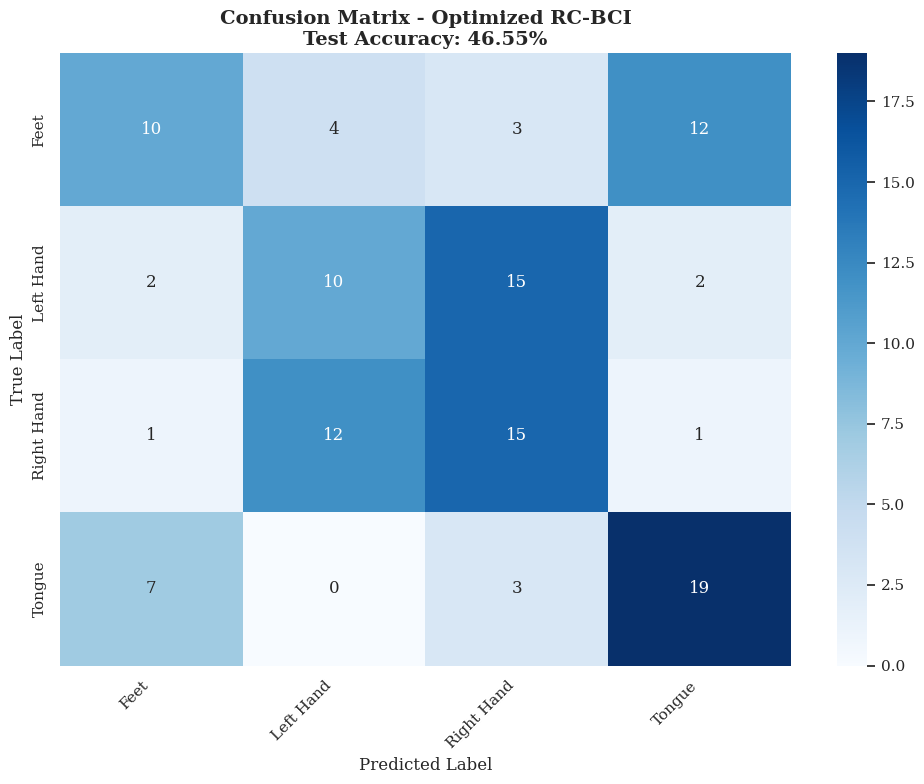

Confusion matrix saved to assets/optuna_confusion_matrix.png


In [49]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"Confusion Matrix - Optimized RC-BCI\nTest Accuracy: {test_accuracy*100:.2f}%",
          fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../assets/optuna_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to assets/optuna_confusion_matrix.png")

## 8. Summary and Best Configuration

In [50]:
# Print final summary
print("="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)

print(f"\nTotal trials: {len(study.trials)}")
print(f"Best CV accuracy: {study.best_value * 100:.2f}%")
print(f"Final test accuracy: {test_accuracy * 100:.2f}%")

print(f"\n{'='*60}")
print("BEST HYPERPARAMETERS")
print(f"{'='*60}")

print(f"""
model = ReservoirBCI(
    units={best_params['units']},
    lr={best_params['lr']:.6f},
    sr={best_params['sr']:.6f},
    ridge={best_params['ridge']:.2e},
    input_scaling={best_params['input_scaling']:.6f},
    rc_connectivity={best_params['rc_connectivity']:.6f},
    warmup={best_params['warmup']}
)
""")

print("="*60)

OPTIMIZATION SUMMARY

Total trials: 24
Best CV accuracy: 53.91%
Final test accuracy: 46.55%

BEST HYPERPARAMETERS

model = ReservoirBCI(
    units=1400,
    lr=0.244873,
    sr=0.719882,
    ridge=3.05e-04,
    input_scaling=0.731150,
    rc_connectivity=0.100150,
    warmup=10
)

